<a href="https://colab.research.google.com/github/aslammowlana99-oss/NorthStar_Analytics_Project/blob/main/northstar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
DATA_PATH = '/content/drive/MyDrive/NorthStar/'   # change to your folder if needed

deliveries = pd.read_csv(DATA_PATH + 'deliveries.csv')
orders     = pd.read_csv(DATA_PATH + 'orders.csv')
drivers    = pd.read_csv(DATA_PATH + 'drivers.csv')
customers  = pd.read_csv(DATA_PATH + 'customers.csv')
complaints = pd.read_csv(DATA_PATH + 'complaints.csv')
incidents  = pd.read_csv(DATA_PATH + 'incidents.csv')
vehicles   = pd.read_csv(DATA_PATH + 'vehicles.csv')
hubs       = pd.read_csv(DATA_PATH + 'hubs.csv')

print("=== Dataset Shapes ===")
for name, df in [('deliveries',deliveries),('orders',orders),('drivers',drivers),
                 ('customers',customers),('complaints',complaints),
                 ('incidents',incidents),('vehicles',vehicles),('hubs',hubs)]:
    print(f"  {name:<12}: {df.shape[0]:>5} rows  x  {df.shape[1]:>2} cols")

=== Dataset Shapes ===
  deliveries  :   950 rows  x  13 cols
  orders      :  1250 rows  x  11 cols
  drivers     :   170 rows  x   8 cols
  customers   :   650 rows  x   9 cols
  complaints  :   320 rows  x  10 cols
  incidents   :   280 rows  x   7 cols
  vehicles    :   120 rows  x   8 cols
  hubs        :     8 rows  x   5 cols


In [6]:
print("=== deliveries.csv — first 3 rows ===")
display(deliveries.head(3))
print("\n=== orders.csv — first 3 rows ===")
display(orders.head(3))

=== deliveries.csv — first 3 rows ===


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51



=== orders.csv — first 3 rows ===


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0


In [7]:
print("=== Data Types & Missing Values ===")
for name, df in [('deliveries',deliveries),('orders',orders),('drivers',drivers),
                 ('customers',customers),('complaints',complaints),('incidents',incidents)]:
    missing = df.isnull().sum()
    if missing.any():
        print(f"\n{name}:")
        print(missing[missing > 0].to_string())

=== Data Types & Missing Values ===

deliveries:
delivery_completed_at            19
customer_rating_post_delivery    14

orders:
booking_channel    25

drivers:
training_score    7

customers:
loyalty_score        20
preferred_channel    13

complaints:
compensation_amount    16

incidents:
resolved_hours    17


In [9]:
print("=== Unique pickup_zone values (inconsistent casing) ===")
print(sorted(orders['pickup_zone'].dropna().unique()))

print("\n=== Unique delivery_status values ===")
print(deliveries['delivery_status'].value_counts().to_dict())

print("\n=== Unique service_type values ===")
print(orders['service_type'].value_counts().to_dict())  # ← Added missing closing parenthesis

=== Unique pickup_zone values (inconsistent casing) ===
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

=== Unique delivery_status values ===
{'OnTime': 616, 'Delayed': 202, 'Failed': 132}

=== Unique service_type values ===
{'Passenger': 341, 'Parcel': 308, 'Retail': 297, 'Business': 165, 'Medical': 139}


In [10]:
ZONE_MAP = {
    'AIRPORT':'Airport',  'airport':'Airport',  'Ctr':'Central',
    'CENTRAL':'Central',  'NORTH':'North',       'north':'North',
    'SOUTH':'South',      'EAST':'East',         'WEST':'West',
    'RiverSide':'Riverside', 'RIVERSIDE':'Riverside'
}

for df in [orders, drivers, customers, vehicles]:
    for col in ['pickup_zone','dropoff_zone','base_zone','home_zone','assigned_zone']:
        if col in df.columns:
            df[col] = df[col].replace(ZONE_MAP).str.strip()

print("Cleaned pickup_zone values:")
print(sorted(orders['pickup_zone'].dropna().unique()))

Cleaned pickup_zone values:
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [11]:
deliveries['dispatch_time']        = pd.to_datetime(deliveries['dispatch_time'], errors='coerce')
deliveries['delivery_completed_at']= pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')
orders['order_created_at']         = pd.to_datetime(orders['order_created_at'], errors='coerce')
complaints['created_at']           = pd.to_datetime(complaints['created_at'], errors='coerce')
incidents['reported_at']           = pd.to_datetime(incidents['reported_at'], errors='coerce')

print("Datetime columns parsed successfully.")

Datetime columns parsed successfully.


In [12]:
deliveries['delivery_duration_hours'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

# Flag negative durations as data errors → set to NaN
neg_count = (deliveries['delivery_duration_hours'] < 0).sum()
print(f"Negative durations (data errors): {neg_count}")
deliveries.loc[deliveries['delivery_duration_hours'] < 0, 'delivery_duration_hours'] = np.nan

# Binary failure flag
deliveries['is_failed']  = (deliveries['delivery_status'] == 'Failed').astype(int)
deliveries['is_delayed'] = (deliveries['delivery_status'] == 'Delayed').astype(int)
deliveries['is_late']    = (deliveries['delivery_status'].isin(['Failed','Delayed'])).astype(int)

# Dispatch hour (for time-of-day analysis)
deliveries['dispatch_hour'] = deliveries['dispatch_time'].dt.hour

# Order month
orders['order_month'] = orders['order_created_at'].dt.to_period('M').astype(str)

print("Feature engineering complete.")
print(deliveries[['delivery_status','is_failed','is_delayed','is_late','delivery_duration_hours']].head())

Negative durations (data errors): 64
Feature engineering complete.
  delivery_status  is_failed  is_delayed  is_late  delivery_duration_hours
0          Failed          1           0        1                22.149973
1          OnTime          0           0        0                      NaN
2          OnTime          0           0        0                 1.108991
3         Delayed          0           1        1                23.985584
4          OnTime          0           0        0                 4.042814


In [13]:
deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median(), inplace=True)
deliveries['fuel_or_charge_cost'].fillna(
    deliveries['fuel_or_charge_cost'].median(), inplace=True)

customers['loyalty_score'].fillna(customers['loyalty_score'].median(), inplace=True)
customers['app_engagement_score'].fillna(customers['app_engagement_score'].median(), inplace=True)

complaints['resolution_days'].fillna(complaints['resolution_days'].median(), inplace=True)
complaints['compensation_amount'].fillna(0, inplace=True)

incidents['resolved_hours'].fillna(incidents['resolved_hours'].median(), inplace=True)

# Categorical — fill with mode
drivers['training_score'].fillna(drivers['training_score'].median(), inplace=True)
drivers['driver_rating'].fillna(drivers['driver_rating'].median(), inplace=True)

print("Missing values after cleaning:")
for name, df in [('deliveries',deliveries),('orders',orders),
                 ('customers',customers),('complaints',complaints)]:
    print(f"  {name}: {df.isnull().sum().sum()} missing")

Missing values after cleaning:
  deliveries: 102 missing
  orders: 25 missing
  customers: 13 missing
  complaints: 0 missing


In [14]:
print("=== Delivery Status Distribution ===")
status_counts = deliveries['delivery_status'].value_counts()
print(status_counts)
print(f"\nOverall failure rate : {deliveries['is_failed'].mean()*100:.1f}%")
print(f"Overall delay rate   : {deliveries['is_delayed'].mean()*100:.1f}%")
print(f"On-time rate         : {(deliveries['delivery_status']=='OnTime').mean()*100:.1f}%")

=== Delivery Status Distribution ===
delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64

Overall failure rate : 13.9%
Overall delay rate   : 21.3%
On-time rate         : 64.8%


In [15]:
print("=== Delivery Duration (hours) — Summary Stats ===")
print(deliveries['delivery_duration_hours'].describe().round(2))

print("\n=== Order Value — Summary Stats ===")
print(orders['order_value'].describe().round(2))

print("\n=== Customer Rating — Summary Stats ===")
print(deliveries['customer_rating_post_delivery'].describe().round(2))

=== Delivery Duration (hours) — Summary Stats ===
count    867.00
mean      10.32
std        8.46
min        0.02
25%        3.50
50%        7.91
75%       15.53
max       43.46
Name: delivery_duration_hours, dtype: float64

=== Order Value — Summary Stats ===
count    1250.00
mean       91.05
std        60.92
min         2.04
25%        47.92
50%        76.53
75%       121.10
max       510.06
Name: order_value, dtype: float64

=== Customer Rating — Summary Stats ===
count    950.00
mean       3.87
std        0.89
min        1.00
25%        3.37
50%        4.04
75%        4.55
max        5.00
Name: customer_rating_post_delivery, dtype: float64


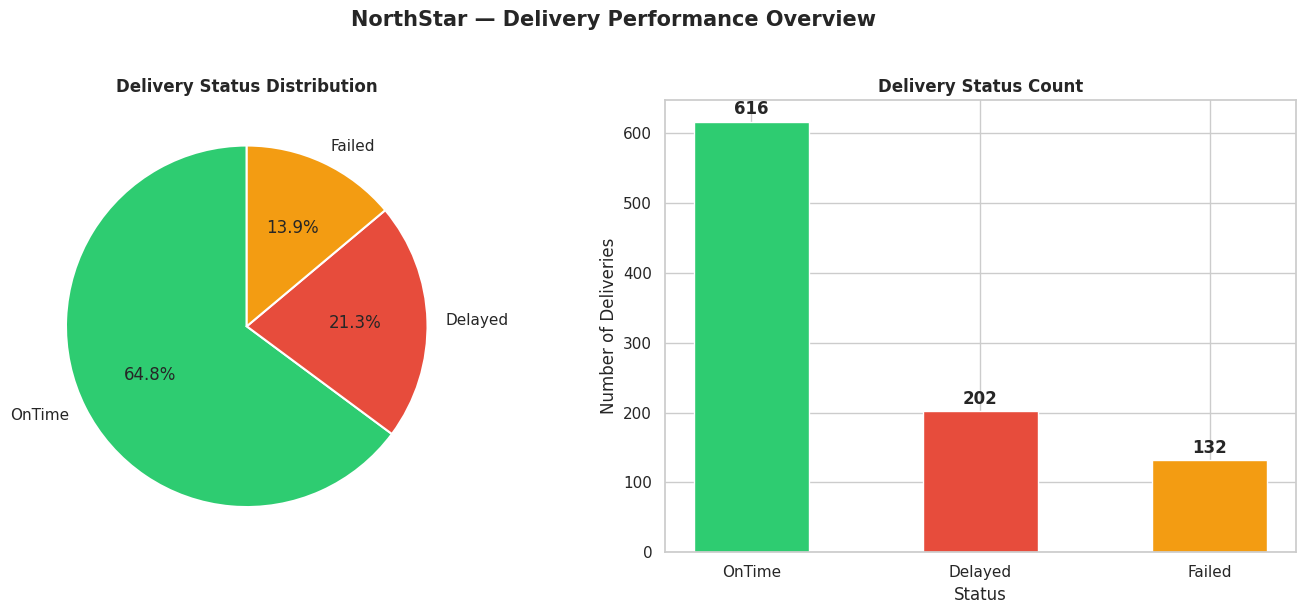

📊 Insight: Over 14% of deliveries failed and 21% were delayed — only 65% were on time.


In [17]:
import matplotlib.pyplot as plt

# Prepare data (assuming you have status_counts from before)
# If not, calculate it:
status_counts = deliveries['delivery_status'].value_counts()

# Create figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Colors
colors = ['#2ecc71', '#e74c3c', '#f39c12']  # Green, Red, Orange

# Pie chart
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Delivery Status Distribution', fontweight='bold', fontsize=12)

# Bar chart
bars = axes[1].bar(status_counts.index, status_counts.values, color=colors,
                   edgecolor='white', width=0.5)
axes[1].set_title('Delivery Status Count', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Number of Deliveries')
axes[1].set_xlabel('Status')

# Add value labels on top of bars
for bar, val in zip(bars, status_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontweight='bold')

# Overall title
plt.suptitle('NorthStar — Delivery Performance Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_delivery_status.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Insight: Over 14% of deliveries failed and 21% were delayed — only 65% were on time.")

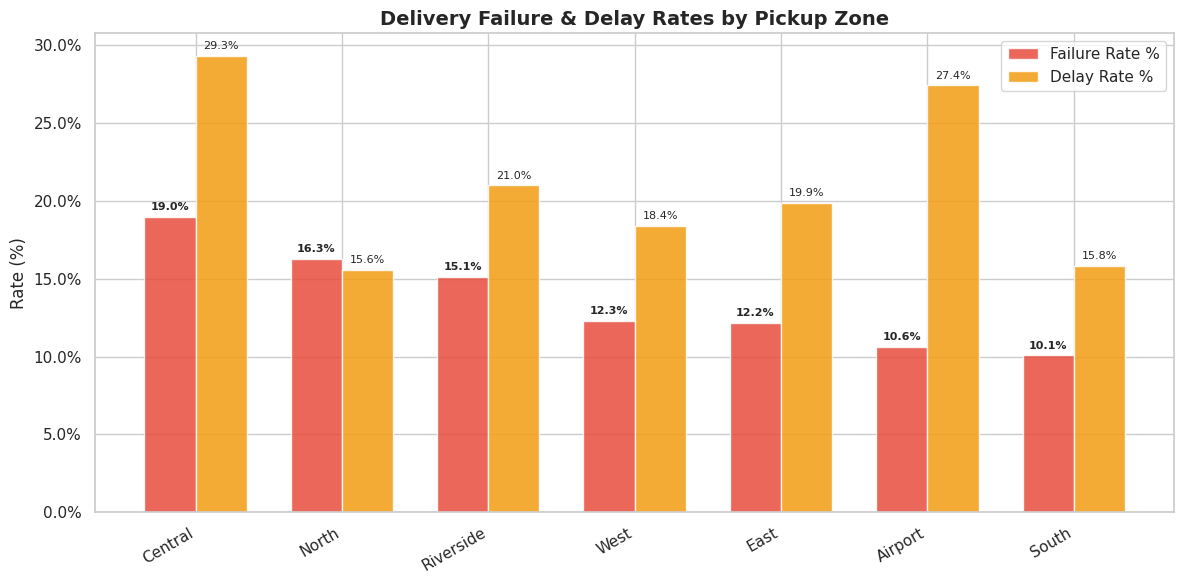

Top 3 highest failure zones:
pickup_zone  failure_rate  delay_rate
    Central     18.965517   29.310345
      North     16.296296   15.555556
  Riverside     15.126050   21.008403


In [18]:
merged = deliveries.merge(orders[['order_id','pickup_zone','service_type','order_value']],
                          on='order_id', how='left')

zone_stats = merged.groupby('pickup_zone').agg(
    total        = ('delivery_id','count'),
    failed       = ('is_failed','sum'),
    delayed      = ('is_delayed','sum'),
    avg_rating   = ('customer_rating_post_delivery','mean')
).reset_index()
zone_stats['failure_rate'] = zone_stats['failed'] / zone_stats['total'] * 100
zone_stats['delay_rate']   = zone_stats['delayed'] / zone_stats['total'] * 100
zone_stats = zone_stats.sort_values('failure_rate', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(zone_stats))
w = 0.35
bars1 = ax.bar(x - w/2, zone_stats['failure_rate'], w, label='Failure Rate %', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + w/2, zone_stats['delay_rate'],   w, label='Delay Rate %',   color='#f39c12', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(zone_stats['pickup_zone'], rotation=30, ha='right')
ax.set_ylabel('Rate (%)')
ax.set_title('Delivery Failure & Delay Rates by Pickup Zone', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig('chart2_zone_failure.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 3 highest failure zones:")
print(zone_stats[['pickup_zone','failure_rate','delay_rate']].head(3).to_string(index=False))

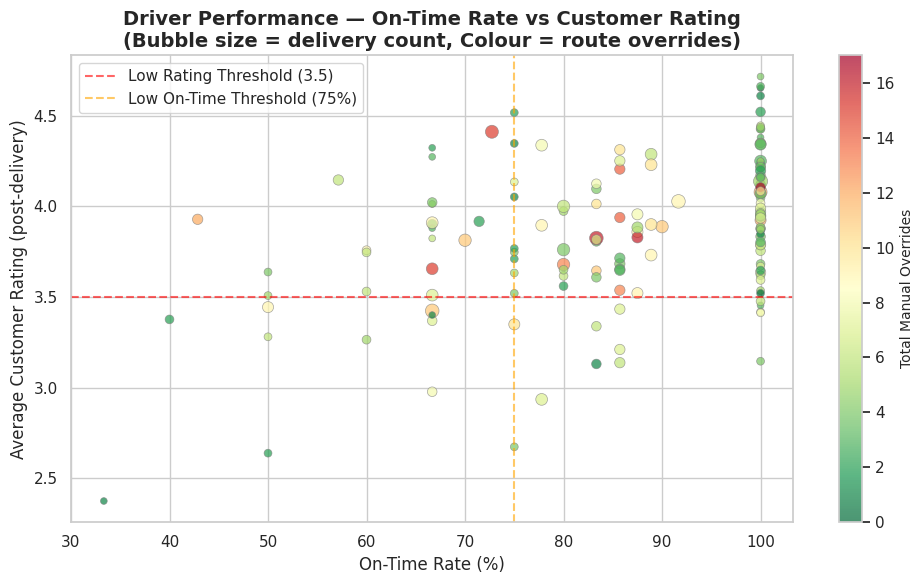

High-risk drivers (low rating AND low on-time): 10


In [19]:
driver_perf = deliveries.groupby('driver_id').agg(
    total_deliveries = ('delivery_id','count'),
    ontime_rate      = ('is_failed', lambda x: (1 - x.mean()) * 100),
    avg_rating       = ('customer_rating_post_delivery','mean'),
    total_overrides  = ('manual_route_override_count','sum')
).reset_index()
driver_perf = driver_perf[driver_perf['total_deliveries'] >= 3]

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    driver_perf['ontime_rate'], driver_perf['avg_rating'],
    c=driver_perf['total_overrides'], cmap='RdYlGn_r',
    s=driver_perf['total_deliveries']*8, alpha=0.7, edgecolors='grey', linewidths=0.5
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Total Manual Overrides', fontsize=10)

ax.axhline(y=3.5, color='red', linestyle='--', alpha=0.6, label='Low Rating Threshold (3.5)')
ax.axvline(x=75, color='orange', linestyle='--', alpha=0.6, label='Low On-Time Threshold (75%)')
ax.set_xlabel('On-Time Rate (%)')
ax.set_ylabel('Average Customer Rating (post-delivery)')
ax.set_title('Driver Performance — On-Time Rate vs Customer Rating\n(Bubble size = delivery count, Colour = route overrides)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('chart3_driver_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"High-risk drivers (low rating AND low on-time): {((driver_perf['avg_rating']<3.5) & (driver_perf['ontime_rate']<75)).sum()}")

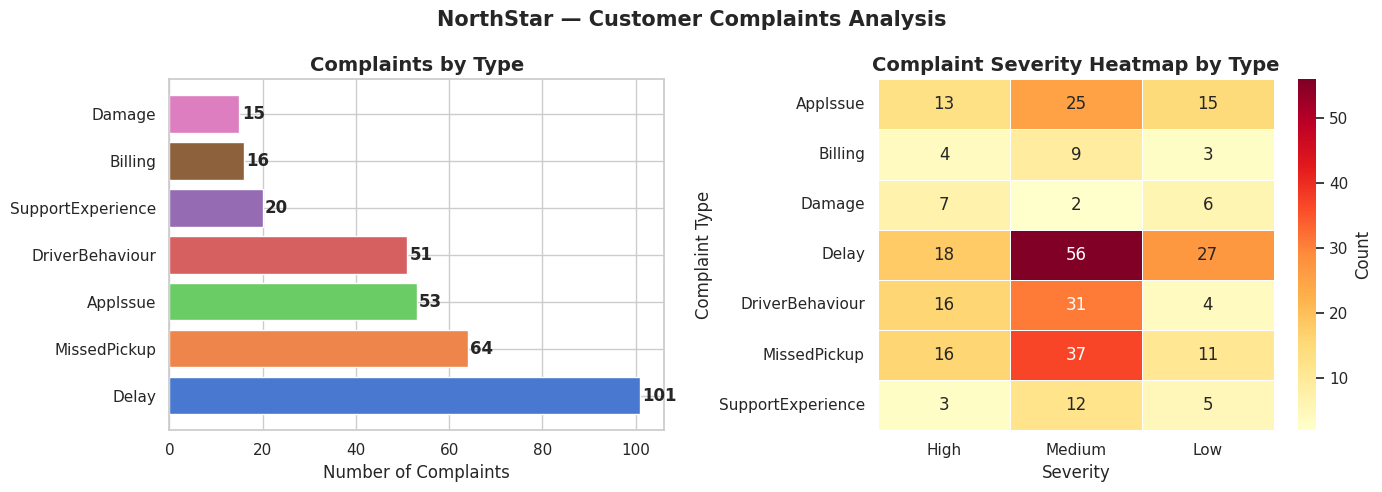

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Complaint type counts
ctype = complaints['complaint_type'].value_counts()
axes[0].barh(ctype.index, ctype.values, color=sns.color_palette("muted", len(ctype)))
axes[0].set_title('Complaints by Type', fontweight='bold')
axes[0].set_xlabel('Number of Complaints')
for i, v in enumerate(ctype.values):
    axes[0].text(v+0.5, i, str(v), va='center', fontweight='bold')

# Severity heatmap by complaint type
pivot = complaints.groupby(['complaint_type','severity']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=['High','Medium','Low'], fill_value=0)
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
            linewidths=0.5, cbar_kws={'label':'Count'})
axes[1].set_title('Complaint Severity Heatmap by Type', fontweight='bold')
axes[1].set_xlabel('Severity')
axes[1].set_ylabel('Complaint Type')

plt.suptitle('NorthStar — Customer Complaints Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_complaints.png', dpi=150, bbox_inches='tight')
plt.show()

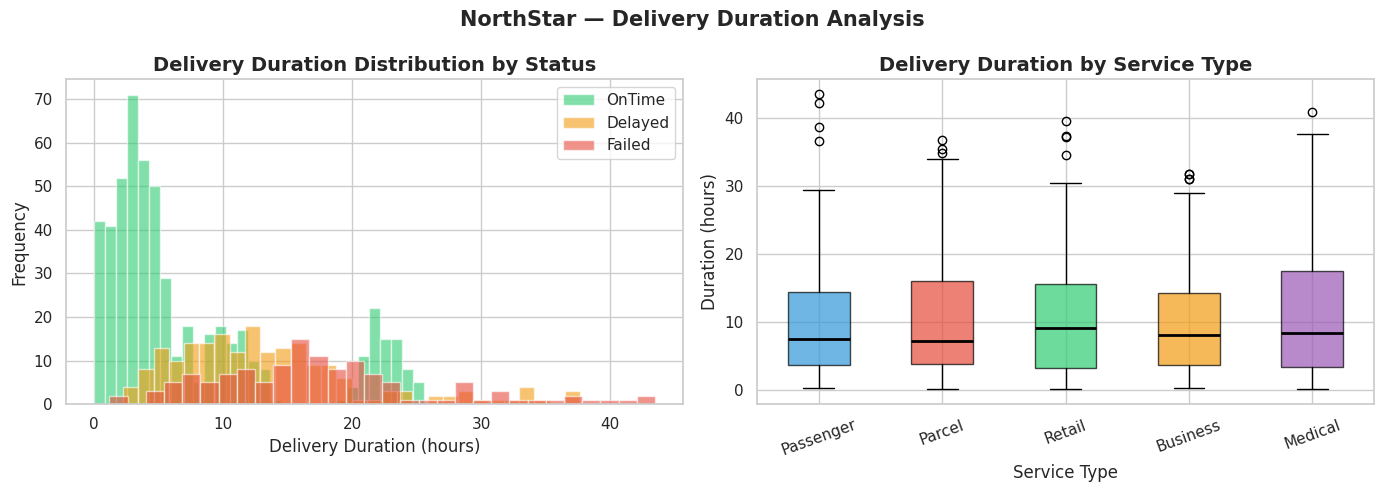

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by status
for status, color in [('OnTime','#2ecc71'),('Delayed','#f39c12'),('Failed','#e74c3c')]:
    subset = deliveries[deliveries['delivery_status']==status]['delivery_duration_hours'].dropna()
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=status, edgecolor='white')
axes[0].set_xlabel('Delivery Duration (hours)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Delivery Duration Distribution by Status', fontweight='bold')
axes[0].legend()

# Box plot by service type
merged2 = deliveries.merge(orders[['order_id','service_type']], on='order_id', how='left')
order_cat = ['Passenger','Parcel','Retail','Business','Medical']
data_bp = [merged2[merged2['service_type']==s]['delivery_duration_hours'].dropna() for s in order_cat]
bp = axes[1].boxplot(data_bp, labels=order_cat, patch_artist=True, notch=False,
                     medianprops={'color':'black','linewidth':2})
colors_bp = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xlabel('Service Type')
axes[1].set_ylabel('Duration (hours)')
axes[1].set_title('Delivery Duration by Service Type', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('NorthStar — Delivery Duration Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_duration.png', dpi=150, bbox_inches='tight')
plt.show()

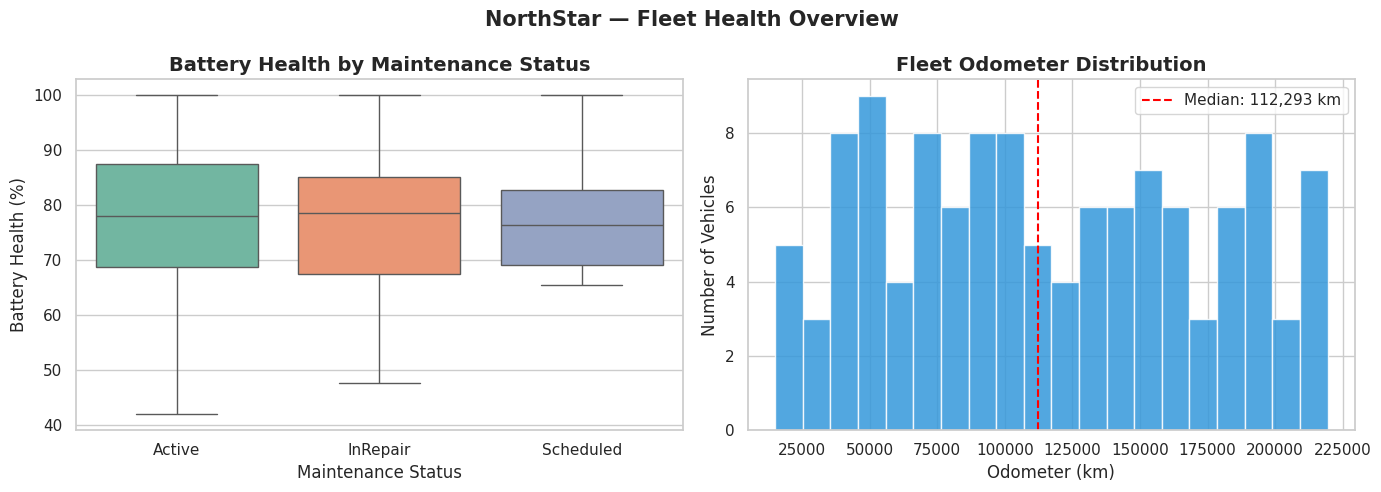

=== Vehicle Maintenance Status Counts ===
{'Active': 67, 'InRepair': 36, 'Scheduled': 17}

Average battery health: 76.8%
Vehicles with battery < 60%: 13


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Battery health by maintenance status
sns.boxplot(data=vehicles, x='maintenance_status', y='battery_health_pct',
            palette='Set2', ax=axes[0])
axes[0].set_title('Battery Health by Maintenance Status', fontweight='bold')
axes[0].set_xlabel('Maintenance Status')
axes[0].set_ylabel('Battery Health (%)')

# Odometer distribution
axes[1].hist(vehicles['odometer_km'].dropna(), bins=20, color='#3498db', edgecolor='white', alpha=0.85)
axes[1].axvline(vehicles['odometer_km'].median(), color='red', linestyle='--',
                label=f"Median: {vehicles['odometer_km'].median():,.0f} km")
axes[1].set_xlabel('Odometer (km)')
axes[1].set_ylabel('Number of Vehicles')
axes[1].set_title('Fleet Odometer Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('NorthStar — Fleet Health Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6_fleet.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Vehicle Maintenance Status Counts ===")
print(vehicles['maintenance_status'].value_counts().to_dict())
print(f"\nAverage battery health: {vehicles['battery_health_pct'].mean():.1f}%")
print(f"Vehicles with battery < 60%: {(vehicles['battery_health_pct'] < 60).sum()}")

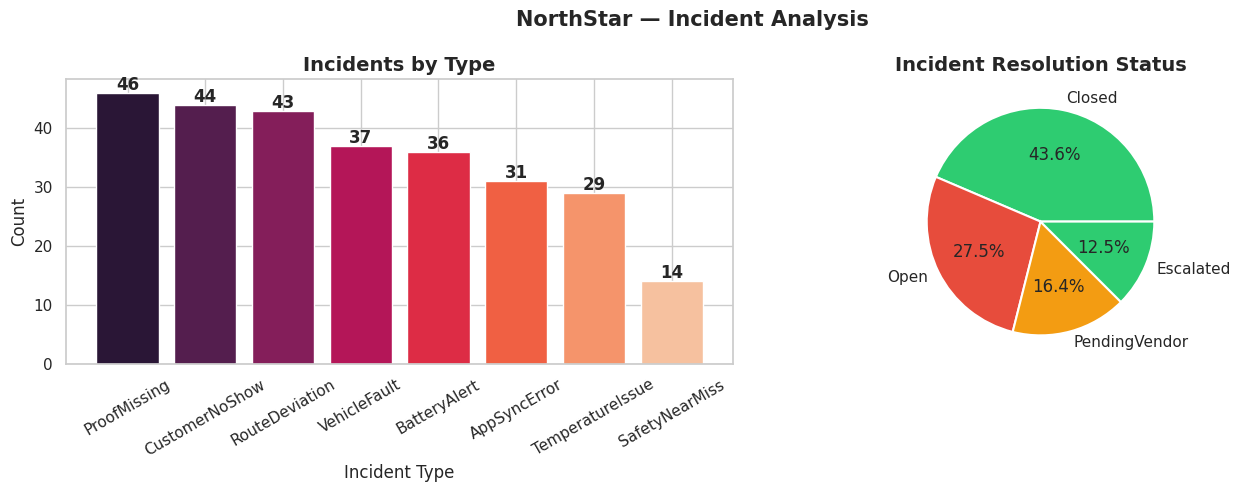

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Incident types
itype = incidents['incident_type'].value_counts()
axes[0].bar(itype.index, itype.values, color=sns.color_palette("rocket", len(itype)), edgecolor='white')
axes[0].set_title('Incidents by Type', fontweight='bold')
axes[0].set_xlabel('Incident Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(itype.values):
    axes[0].text(i, v+0.5, str(v), ha='center', fontweight='bold')

# Resolution status
res_status = incidents['resolution_status'].value_counts()
axes[1].pie(res_status, labels=res_status.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c','#f39c12'],
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Incident Resolution Status', fontweight='bold')

plt.suptitle('NorthStar — Incident Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_incidents.png', dpi=150, bbox_inches='tight')
plt.show()

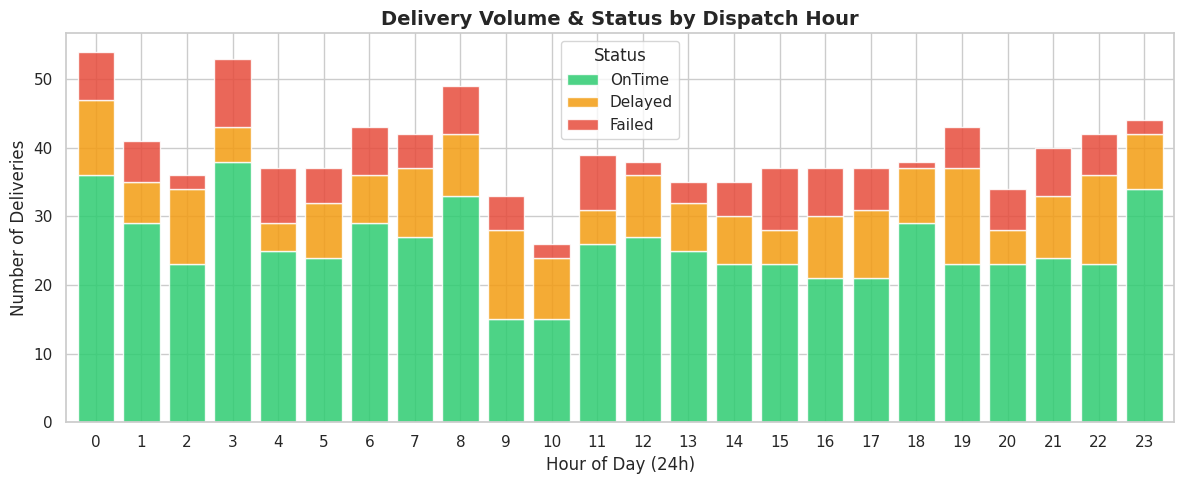

Peak dispatch hours: [0, 3, 8]


In [24]:
hourly = deliveries.groupby(['dispatch_hour','delivery_status']).size().unstack(fill_value=0)
hourly = hourly.reindex(columns=['OnTime','Delayed','Failed'], fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
hourly.plot(kind='bar', ax=ax, color=['#2ecc71','#f39c12','#e74c3c'],
            edgecolor='white', width=0.8, stacked=True, alpha=0.85)
ax.set_xlabel('Hour of Day (24h)')
ax.set_ylabel('Number of Deliveries')
ax.set_title('Delivery Volume & Status by Dispatch Hour', fontweight='bold')
ax.legend(title='Status')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('chart8_hourly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Peak dispatch hours:", hourly.sum(axis=1).nlargest(3).index.tolist())

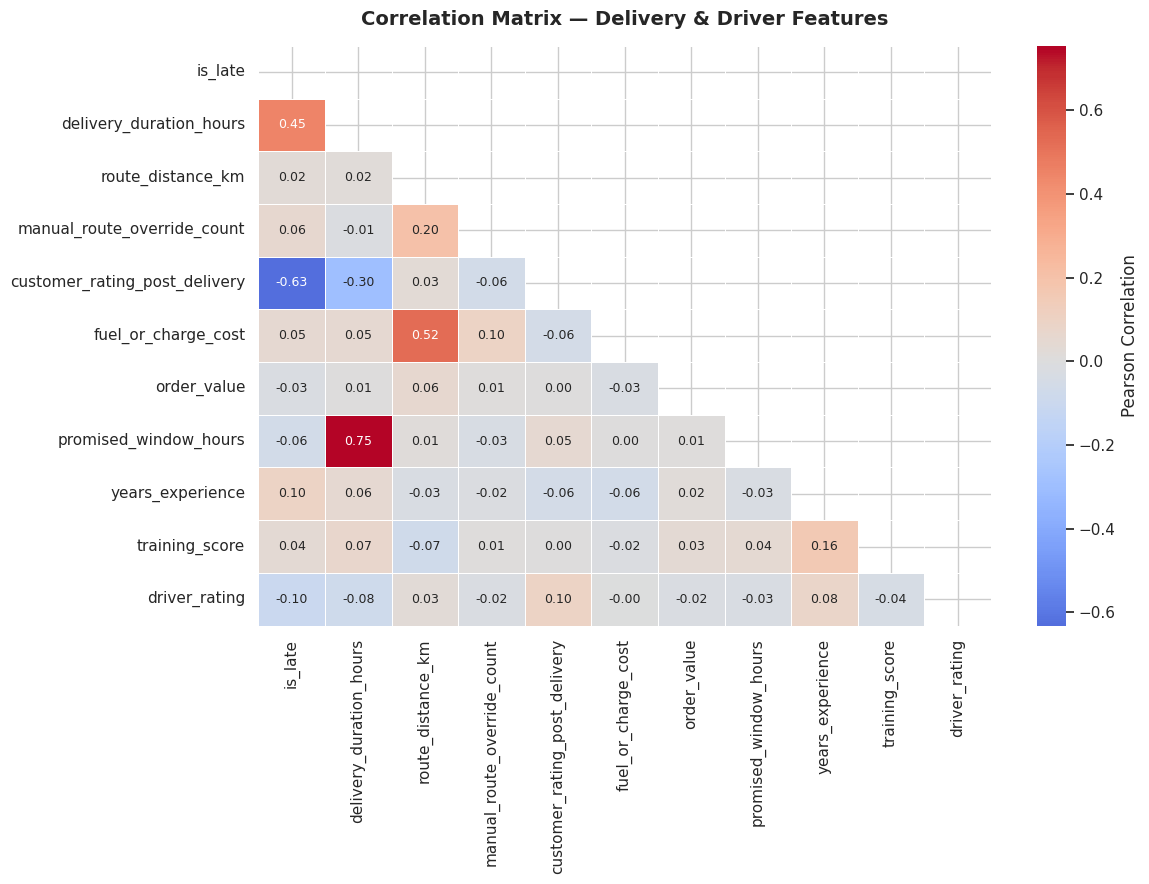


=== Strongest correlations with delivery failure/delay ===
customer_rating_post_delivery   -0.632
delivery_duration_hours          0.449
driver_rating                   -0.103
years_experience                 0.096
promised_window_hours           -0.061
manual_route_override_count      0.061
fuel_or_charge_cost              0.051
training_score                   0.036
order_value                     -0.025
route_distance_km                0.024
Name: is_late, dtype: float64


In [25]:
# Merge for full numeric dataset
full = deliveries.merge(orders[['order_id','order_value','promised_window_hours','special_handling_flag']],
                        on='order_id', how='left')
full = full.merge(drivers[['driver_id','years_experience','training_score','driver_rating']],
                  on='driver_id', how='left')

corr_cols = ['is_late','delivery_duration_hours','route_distance_km','manual_route_override_count',
             'customer_rating_post_delivery','fuel_or_charge_cost','order_value',
             'promised_window_hours','years_experience','training_score','driver_rating']

corr_matrix = full[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size':9},
            cbar_kws={'label':'Pearson Correlation'})
ax.set_title('Correlation Matrix — Delivery & Driver Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart9_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print strongest correlations with is_late
print("\n=== Strongest correlations with delivery failure/delay ===")
print(corr_matrix['is_late'].drop('is_late').sort_values(key=abs, ascending=False).round(3))

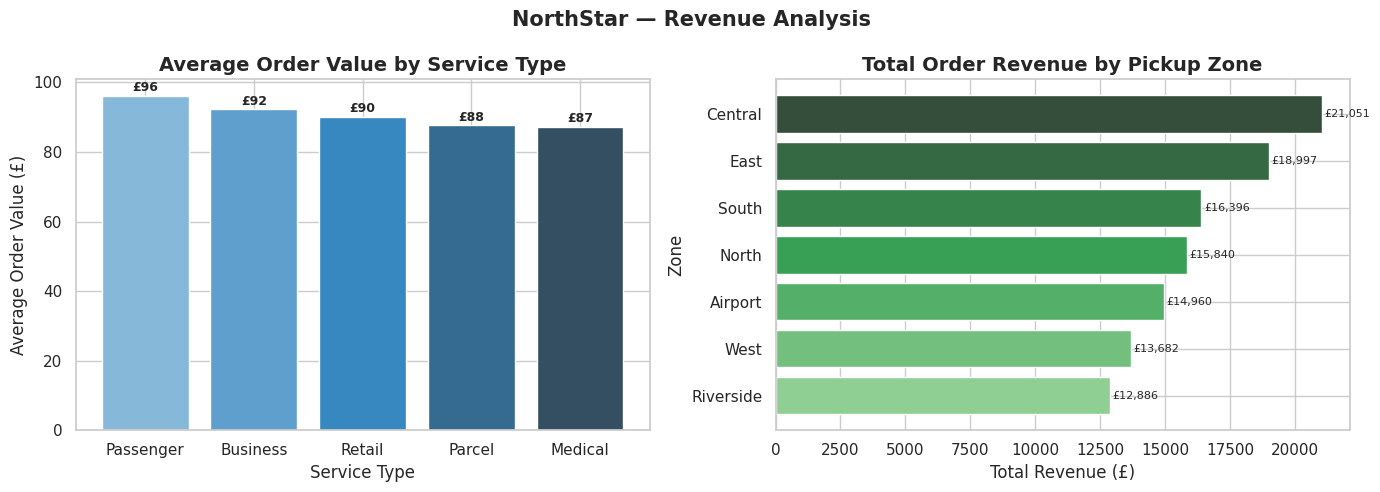

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average order value by service type
svc_value = orders.groupby('service_type')['order_value'].agg(['mean','sum','count']).reset_index()
svc_value = svc_value.sort_values('mean', ascending=False)
bars = axes[0].bar(svc_value['service_type'], svc_value['mean'],
                   color=sns.color_palette("Blues_d", len(svc_value)), edgecolor='white')
for bar, val in zip(bars, svc_value['mean']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'£{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].set_title('Average Order Value by Service Type', fontweight='bold')
axes[0].set_xlabel('Service Type')
axes[0].set_ylabel('Average Order Value (£)')

# Total revenue by pickup zone
zone_rev = orders.groupby('pickup_zone')['order_value'].sum().sort_values(ascending=True)
axes[1].barh(zone_rev.index, zone_rev.values,
             color=sns.color_palette("Greens_d", len(zone_rev)))
axes[1].set_title('Total Order Revenue by Pickup Zone', fontweight='bold')
axes[1].set_xlabel('Total Revenue (£)')
axes[1].set_ylabel('Zone')
for i, v in enumerate(zone_rev.values):
    axes[1].text(v+100, i, f'£{v:,.0f}', va='center', fontsize=8)

plt.suptitle('NorthStar — Revenue Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('chart10_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
print("=" * 58)
print("     NORTHSTAR — KEY ANALYTICAL FINDINGS")
print("=" * 58)

total = len(deliveries)
failed = deliveries['is_failed'].sum()
delayed = deliveries['is_delayed'].sum()
ontime = (deliveries['delivery_status']=='OnTime').sum()

print(f"\n DELIVERY PERFORMANCE")
print(f"   Total deliveries  : {total}")
print(f"   On-Time           : {ontime} ({ontime/total*100:.1f}%)")
print(f"   Delayed           : {delayed} ({delayed/total*100:.1f}%)")
print(f"   Failed            : {failed}  ({failed/total*100:.1f}%)")

worst_zone = zone_stats.iloc[0]
print(f"\n ZONE ANALYSIS")
print(f"   Worst zone        : {worst_zone['pickup_zone']} ({worst_zone['failure_rate']:.1f}% failure rate)")
print(f"   Best zone         : {zone_stats.iloc[-1]['pickup_zone']} ({zone_stats.iloc[-1]['failure_rate']:.1f}% failure rate)")

high_risk = driver_perf[(driver_perf['avg_rating']<3.5) & (driver_perf['ontime_rate']<75)]
print(f"\n DRIVER PERFORMANCE")
print(f"   Drivers analysed  : {len(driver_perf)}")
print(f"   High-risk drivers : {len(high_risk)} (low rating + low on-time)")
print(f"   Best on-time rate : {driver_perf['ontime_rate'].max():.1f}%")

print(f"\n  INCIDENTS")
print(f"   Total incidents   : {len(incidents)}")
print(f"   Unresolved (Open) : {(incidents['resolution_status']=='Open').sum()}")
print(f"   Escalated         : {(incidents['resolution_status']=='Escalated').sum()}")

print(f"\n COMPLAINTS")
print(f"   Total complaints  : {len(complaints)}")
print(f"   High severity     : {(complaints['severity']=='High').sum()}")
print(f"   Open status       : {(complaints['status']=='Open').sum()}")
print(f"   Total compensation: £{complaints['compensation_amount'].sum():,.2f}")

print(f"\n FLEET STATUS")
inrepair = (vehicles['maintenance_status']=='InRepair').sum()
print(f"   Total vehicles    : {len(vehicles)}")
print(f"   In Repair         : {inrepair} ({inrepair/len(vehicles)*100:.1f}%)")
print(f"   Avg battery health: {vehicles['battery_health_pct'].mean():.1f}%")
print("=" * 58)

     NORTHSTAR — KEY ANALYTICAL FINDINGS

 DELIVERY PERFORMANCE
   Total deliveries  : 950
   On-Time           : 616 (64.8%)
   Delayed           : 202 (21.3%)
   Failed            : 132  (13.9%)

 ZONE ANALYSIS
   Worst zone        : Central (19.0% failure rate)
   Best zone         : South (10.1% failure rate)

 DRIVER PERFORMANCE
   Drivers analysed  : 151
   High-risk drivers : 10 (low rating + low on-time)
   Best on-time rate : 100.0%

  INCIDENTS
   Total incidents   : 280
   Unresolved (Open) : 77
   Escalated         : 35

 COMPLAINTS
   Total complaints  : 320
   High severity     : 77
   Open status       : 56
   Total compensation: £6,158.19

 FLEET STATUS
   Total vehicles    : 120
   In Repair         : 36 (30.0%)
   Avg battery health: 76.8%
